# Weight Pruning — Comet Sweep Analysis

Analyses for the 5 comet sweeps in `paper-weight-pruning-scaling-sweep`:

- **dense_fill_main**: block_sparse → dense fill experiment at n=16, h=256.
- **n_task_scaling**: block_sparse / dense / random_sparse / structure_search, each sweeping `task.n_tasks` × a size axis × LRs.

All sweeps log per-seed `(n_log_periods, n_seeds)` arrays as comet assets (`per_seed_losses.npy`, `per_seed_accs.npy`). Live metric series carry only the across-seed mean+std; the per-seed assets are loaded here to compute real 95% CI bands.

In [33]:
# # Run once to fetch from Comet. Comment out after first run.
# from phd.research_utils.scripts.comet_download import run as _comet_download
# _comet_download(
#     project='paper-weight-pruning-scaling-sweep',
#     output_dir='data',
# )

In [34]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import io
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import t as t_dist

from comet_ml.api import API

from phd.research_utils.analysis.analysis_utils import (
    set_matplotlib_style, get_color_palette, save_fig_versions,
)
from phd.research_utils.analysis.plotting import (
    plot_param_sensitivity,
)

set_matplotlib_style('2-row')
%matplotlib inline

PROJECT = 'paper-weight-pruning-scaling-sweep'
SWEEP_IDS = {
    'dense_fill_main':    'dc6d3df68d25479999b72a32af29c275',
    'n_block_sparse':     'bf92bf7c1ced4535823e892b8049089d',
    'n_dense':            'b21316aca20d4aa7b60d05f03d59babc',
    'n_random_sparse':    'ac0163f45597446fbdea4a12edffd3ab',
    'n_structure_search': 'eb0849167ea44728a1173f9a794fd165',
}
SWEEP_NAMES = {
    'dense_fill_main':    '00_block_sparse_dense_fill_main_n16_h256',
    'n_block_sparse':     '00_block_sparse_n_task_scaling_lr_5seed',
    'n_dense':            '00_dense_n_task_scaling_lr_5seed',
    'n_random_sparse':    '00_random_sparse_n_task_scaling_lr_5seed',
    'n_structure_search': '00_structure_search_n_task_scaling_lr_5seed',
}

DATA_DIR    = Path('data')
ASSET_CACHE = DATA_DIR / 'per_seed_cache'
ASSET_CACHE.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    save_fig_versions(name, dir='figures/pdf/', type='pdf')
    save_fig_versions(name, dir='figures/png/', type='png')

## Load data

`comet_download` dumps two CSVs: one with per-trial parameters, one with the metric history. The metric history uses Comet's `step` index, which the train script sets to the global training step at each log period.

In [35]:
PARAMS_PATH  = DATA_DIR / f'{PROJECT}_params.csv'
METRICS_PATH = DATA_DIR / f'{PROJECT}_metrics.csv'

cfg_all = pd.read_csv(PARAMS_PATH, index_col=0)
run_all = pd.read_csv(METRICS_PATH, index_col=0)

# Sweep-axis params are logged twice by comet_download: the `foo.bar` dotted
# form is the raw CLI-override string (which may still contain unevaluated
# `${eval:...}` interpolations), while the `foo|bar` pipe form is the
# resolved value from the Hydra cfg. Prefer the pipe form when available.
_PIPE_TO_DOTTED = {
    'task|n_tasks':                          'task.n_tasks',
    'task|permute_period':                   'task.permute_period',
    'model|initial_hidden_units':            'model.initial_hidden_units',
    'model|max_hidden_units':                'model.max_hidden_units',
    'optimizer|learning_rate':               'optimizer.learning_rate',
    'structure_search|connection_budget':    'structure_search.connection_budget',
    'structure_search|prune_count':          'structure_search.prune_count',
    'structure_search|max_units_per_event':  'structure_search.max_units_per_event',
    'train|log_freq':                        'train.log_freq',
    'train|total_steps':                     'train.total_steps',
    'train|batch_size':                      'train.batch_size',
}
for pipe, dotted in _PIPE_TO_DOTTED.items():
    if pipe in cfg_all.columns:
        cfg_all[dotted] = cfg_all[pipe]

_NUMERIC_COLS = [
    'task.n_tasks', 'model.initial_hidden_units', 'model.max_hidden_units',
    'model.dense_fill_step', 'structure_search.connection_budget',
    'structure_search.prune_count', 'structure_search.max_units_per_event',
    'optimizer.learning_rate', 'seed_offset', 'train.log_freq',
    'train.total_steps',
]
for col in _NUMERIC_COLS:
    if col in cfg_all.columns:
        cfg_all[col] = pd.to_numeric(cfg_all[col], errors='coerce')

# The metrics CSV from comet_download has no explicit `step` column -- rows
# are pre-sorted per run_id by Comet's step index. Reconstruct step from
# (row position within run_id) * log_freq, using each trial's own log_freq.
run_all = run_all.reset_index(drop=True)
log_freq_map = cfg_all.set_index('run_id')['train.log_freq'].to_dict()
run_all['_log_freq'] = run_all['run_id'].map(log_freq_map).astype(float)
run_all['step'] = (run_all.groupby('run_id').cumcount() + 1) * run_all['_log_freq']
run_all = run_all.drop(columns='_log_freq').dropna(subset=['step'])

print(f'{len(cfg_all)} trials, {len(run_all)} metric rows')
print('\nsweep_name counts:')
print(cfg_all['sweep_name'].value_counts())

607 trials, 239738 metric rows

sweep_name counts:
sweep_name
00_dense_n_task_scaling_lr_5seed               174
00_block_sparse_n_task_scaling_lr_5seed        145
00_structure_search_n_task_scaling_lr_5seed    130
00_random_sparse_n_task_scaling_lr_5seed       126
00_block_sparse_dense_fill_main_n16_h256        32
Name: count, dtype: int64


## Helpers

In [ ]:
def filter_sweep(key):
    """Slice cfg+run to one sweep by short key (e.g. 'n_block_sparse')."""
    target = SWEEP_NAMES[key]
    cfg = cfg_all[cfg_all['sweep_name'] == target].copy()
    run = run_all[run_all['run_id'].isin(cfg['run_id'])].copy()
    return cfg, run


def _diverged_run_ids(run):
    """Set of run_ids whose `diverged` summary metric is set (> 0.5).

    This is the train script's authoritative divergence flag (set when the
    early-stop fires on NaN/inf or loss > 1e6). Incomplete-but-not-diverged
    runs are handled separately via report_incomplete_runs -- they are
    *not* nulled here automatically.
    """
    if 'diverged' not in run.columns:
        return set()
    last_div = run.groupby('run_id')['diverged'].apply(
        lambda s: s.dropna().iloc[-1] if s.notna().any() else 0
    )
    return set(last_div[last_div > 0.5].index)


def asymptotic_metric(cfg, run, metric_col, group_cols):
    """Mean of `metric_col` over the last 5% of training steps per trial, then
    aggregated per (group, LR). NaN-propagating: a diverged or NaN trial
    yields NaN per-trial, and any NaN within a (group, LR) cell makes the
    whole cell NaN (so cells with even one bad run show up as gaps in plots,
    not as silently-biased averages).
    """
    diverged = _diverged_run_ids(run)
    per_run = (
        run.groupby('run_id')[metric_col]
        .apply(lambda s: (
            s.dropna().iloc[max(1, int(0.95 * len(s.dropna()))):].mean()
            if len(s.dropna()) > 1 else np.nan
        ))
        .rename('_metric')
    )
    if diverged:
        per_run.loc[per_run.index.intersection(diverged)] = np.nan
    merged = cfg.merge(per_run, left_on='run_id', right_index=True, how='left')
    return (
        merged.groupby(group_cols + ['optimizer.learning_rate'])['_metric']
        .agg(lambda x: x.mean(skipna=False))    # propagate NaN within a cell
        .reset_index()
    )


def filter_to_best(cfg, run, group_cols, metric_col, direction='max'):
    """Keep only the rows whose LR is best within each group (NaN-aware)."""
    asym = asymptotic_metric(cfg, run, metric_col, group_cols)
    # idxmax/idxmin skip NaN by default; that's what we want for picking the
    # best LR among the *non-diverged* options. Groups whose every LR diverged
    # yield NaN here and get filtered out.
    grouped = asym.groupby(group_cols)['_metric']
    idxs = (grouped.idxmax() if direction == 'max' else grouped.idxmin()).dropna()
    best = asym.loc[idxs.astype(int)]
    keep = set(map(tuple, best[group_cols + ['optimizer.learning_rate']].values))
    cfg_keys = list(map(tuple, cfg[group_cols + ['optimizer.learning_rate']].values))
    mask = pd.Series([k in keep for k in cfg_keys], index=cfg.index)
    return cfg[mask].copy(), run[run['run_id'].isin(cfg.loc[mask, 'run_id'])].copy(), best


def report_incomplete_runs(cfg, run, *, completion_threshold=0.95, label='all sweeps'):
    """Print a loud warning about runs that finished < threshold of expected
    log periods but were NOT flagged as diverged.

    These are typically cluster-time-limited (SLURM walltime hit) runs whose
    last-5% asymptotic is taken from a *truncated* tail. They are not auto-
    nullified -- the warning shows you exactly which (sweep, n_tasks, size,
    LR) cells they sit in so you can decide whether the truncation is
    acceptable or whether you need to re-run.
    """
    diverged = _diverged_run_ids(run)
    expected = (cfg['train.total_steps'] / cfg['train.log_freq']).fillna(0)
    expected_per_rid = dict(zip(cfg['run_id'], expected))
    actual = run.groupby('run_id').size().to_dict()

    incomplete = []
    for rid, n_act in actual.items():
        if rid not in expected_per_rid or rid in diverged:
            continue
        n_exp = expected_per_rid[rid]
        if n_exp > 0 and n_act < completion_threshold * n_exp:
            incomplete.append((rid, int(n_act), int(n_exp)))

    bar = '!' * 78
    if not incomplete:
        print(f'\n[OK] No incomplete (non-diverged) runs in {label}.')
        return

    print(f'\n{bar}')
    print(f'!! INCOMPLETE RUNS in {label}: {len(incomplete)} trial(s) {"!" * (40 - len(label))}'[:78])
    print(f'{bar}')
    print(f'Trials below finished < {completion_threshold:.0%} of expected log periods')
    print(f'but were NOT flagged as diverged. Their asymptotic may be from a')
    print(f'truncated tail. Verify these cells before trusting the plots:\n')

    info_cols = ['sweep_name', 'task.n_tasks', 'model.initial_hidden_units',
                 'structure_search.connection_budget',
                 'optimizer.learning_rate',
                 'model.dense_fill_step', 'seed_offset']
    info_cols = [c for c in info_cols if c in cfg.columns]
    cfg_indexed = cfg.set_index('run_id')[info_cols]

    rows = []
    for rid, n_act, n_exp in incomplete:
        row = {'run_id': rid[:10] + '...', 'n_rows': n_act, 'expected': n_exp,
               'pct': f'{100 * n_act / n_exp:.0f}%'}
        if rid in cfg_indexed.index:
            for c in info_cols:
                row[c] = cfg_indexed.loc[rid, c]
        rows.append(row)
    inc_df = pd.DataFrame(rows)
    with pd.option_context('display.width', 200, 'display.max_columns', None):
        print(inc_df.to_string(index=False))
    print(f'\n{bar}\n')


def plot_lr_sensitivity(asym, ax, x_col='optimizer.learning_rate', y_col='_metric',
                        hue_col=None, palette=None, title='', xlabel='Learning rate',
                        ylabel='Asymptotic metric', ylim=None, legend_title=None):
    """Asymptotic metric vs LR on a log-2 x-axis, with NaN-gap-aware lines.

    NaN cells become breaks in the line (no interpolation across divergent
    LRs). The actual LR values are used as x positions so the log-2 spacing
    is visually faithful to the underlying powers of 2.
    """
    if hue_col is None:
        sub = asym.sort_values(x_col)
        ax.plot(sub[x_col], sub[y_col], '-o', color='C0')
    else:
        try:
            hue_vals = sorted(asym[hue_col].dropna().unique(),
                              key=lambda v: float(v))
        except Exception:
            hue_vals = sorted(asym[hue_col].dropna().unique())
        if palette is None:
            colors = sns.color_palette('viridis', n_colors=len(hue_vals))
        else:
            colors = list(palette)
        for hv, color in zip(hue_vals, colors):
            sub = asym[asym[hue_col] == hv].sort_values(x_col)
            label = (f'{int(hv):,}' if float(hv).is_integer() else f'{hv}')
            ax.plot(sub[x_col], sub[y_col], '-o', color=color, label=label)
        ax.legend(title=legend_title or hue_col, fontsize='x-small', loc='best')
    ax.set_xscale('log', base=2)
    lr_vals = sorted(asym[x_col].dropna().unique())
    ax.set_xticks(lr_vals)
    ax.set_xticklabels([f'$2^{{{int(np.log2(v))}}}$' for v in lr_vals])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(True, alpha=0.4)

In [37]:
# Per-seed asset loader (cached + concurrent).
_api_singleton = None
def _api():
    global _api_singleton
    if _api_singleton is None:
        _api_singleton = API()
    return _api_singleton


def fetch_per_seed_arrays(run_ids, n_threads=8):
    """Download per_seed_losses + per_seed_accs for a set of run_ids; cached on disk.

    Returns: dict run_id -> {'losses': arr, 'accs': arr}, each (n_log_periods, n_seeds).
    """
    def fetch_one(run_id):
        cache_l = ASSET_CACHE / f'{run_id}_losses.npy'
        cache_a = ASSET_CACHE / f'{run_id}_accs.npy'
        if cache_l.exists() and cache_a.exists():
            return run_id, {'losses': np.load(cache_l), 'accs': np.load(cache_a)}
        try:
            e = _api().get_experiment_by_key(run_id)
            asset_list = e.get_asset_list()
            by_name = {a['fileName']: a for a in asset_list}
            for asset_name, cache_path in [
                ('per_seed_losses.npy', cache_l),
                ('per_seed_accs.npy',  cache_a),
            ]:
                if asset_name not in by_name:
                    return run_id, None
                data = e.get_asset(by_name[asset_name]['assetId'], return_type='binary')
                arr = np.load(io.BytesIO(data))
                np.save(cache_path, arr)
            return run_id, {'losses': np.load(cache_l), 'accs': np.load(cache_a)}
        except Exception as exc:
            print(f'failed for {run_id}: {exc}')
            return run_id, None

    out = {}
    with ThreadPoolExecutor(max_workers=n_threads) as ex:
        futures = {ex.submit(fetch_one, rid): rid for rid in run_ids}
        for f in tqdm(as_completed(futures), total=len(futures), desc='fetch per-seed'):
            rid, data = f.result()
            if data is not None:
                out[rid] = data
    return out


def stack_per_seed(asset_dict, run_ids):
    """Concat per-seed arrays across a list of run_ids along the seed axis.

    Diverged trials produce *shorter* arrays (the train script early-stops).
    To keep all trials at the same step axis we NaN-pad shorter arrays up to
    the longest length present. With NaN-propagating mean (see plot_ci_curve),
    a single diverged trial nullifies the combined curve past its divergence
    step, so the curve simply ends where any constituent trial ended.

    Returns: (losses, accs), shape (max_n_periods, n_combined_seeds).
    """
    present = [rid for rid in run_ids if rid in asset_dict]
    if not present:
        return None, None
    max_len = max(asset_dict[rid]['losses'].shape[0] for rid in present)

    def pad(arr):
        if arr.shape[0] == max_len:
            return arr
        pad_block = np.full((max_len - arr.shape[0], arr.shape[1]), np.nan,
                            dtype=arr.dtype)
        return np.concatenate([arr, pad_block], axis=0)

    losses = np.concatenate([pad(asset_dict[rid]['losses']) for rid in present], axis=1)
    accs   = np.concatenate([pad(asset_dict[rid]['accs'])   for rid in present], axis=1)
    return losses, accs


def plot_ci_curve(steps, arr, label=None, color=None, alpha=0.20, ax=None):
    """Mean + 95% t-CI band from a (n_periods, n_seeds) array (NaN-propagating).

    A single NaN seed at step t makes mean[t] = NaN, so the line and band
    end at the earliest divergence among the constituent seeds. No silent
    skipping of divergent seeds.
    """
    ax = ax or plt.gca()
    mean = arr.mean(axis=1)           # propagate NaN
    sem  = arr.std(axis=1, ddof=1) / np.sqrt(arr.shape[1])
    half_w = t_dist.ppf(0.975, df=arr.shape[1] - 1) * sem
    ax.plot(steps, mean, label=label, color=color)
    ax.fill_between(steps, mean - half_w, mean + half_w,
                    alpha=alpha, color=color, linewidth=0)

In [ ]:
# Loud warning about any trials that ran short of their expected log-period
# count but were NOT flagged as diverged. These are typically cluster-time-
# limited and their asymptotic is taken from a truncated tail.
#
# Diverged trials are handled separately by asymptotic_metric (they propagate
# NaN through their (group, LR) cell). This report is *only* about silent
# incomplete runs that the divergence detection doesn't catch.
for key, name in SWEEP_NAMES.items():
    cfg_sweep = cfg_all[cfg_all['sweep_name'] == name]
    run_sweep = run_all[run_all['run_id'].isin(cfg_sweep['run_id'])]
    if len(cfg_sweep) == 0:
        continue
    report_incomplete_runs(cfg_sweep, run_sweep, label=name)

## 1. dense_fill_main

n_tasks=16, hidden_units=256, total_steps=500k. The grid is `(dense_fill_step ∈ {0, 250000, 600000}) × (LR ∈ {2^-11..2^-7}) × (seed_offset ∈ {0, 15})`. 600000 is the never-fill sentinel (block_sparse baseline), 0 = dense-from-start with cross-task weights initially 0.

In [38]:
df_cfg, df_run = filter_sweep('dense_fill_main')
df_run['loss_per_task'] = df_run['loss'] / 16
print(f'{len(df_cfg)} trials')

# Sanity: should be 3 fill steps × 5 LRs × 2 seed_offsets = 30 trials.
print(df_cfg.groupby(['model.dense_fill_step', 'seed_offset']).size())

32 trials
model.dense_fill_step  seed_offset
0.0                    0.0            5
                       15.0           5
250000.0               0.0            5
                       15.0           5
600000.0               0.0            6
                       15.0           6
dtype: int64


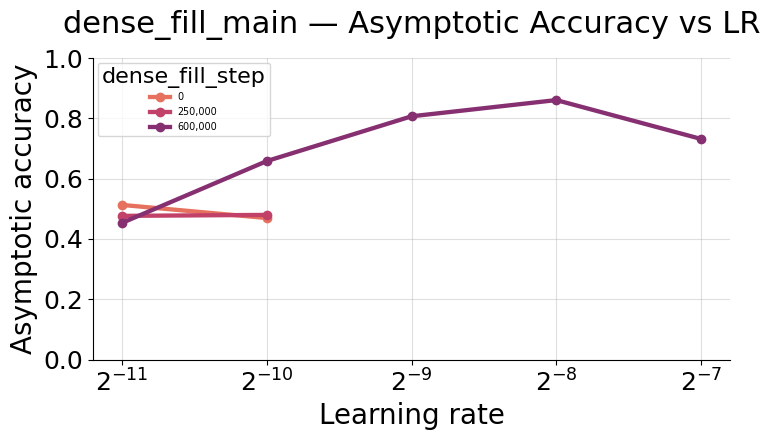

optimizer.learning_rate  0.000488  0.000977  0.001953  0.003906  0.007812
model.dense_fill_step                                                    
0.0                         0.513     0.469       NaN       NaN       NaN
250000.0                    0.476     0.480       NaN       NaN       NaN
600000.0                    0.453     0.658     0.807      0.86     0.732


In [39]:
# LR sensitivity (NaN-propagating: cells whose underlying trial diverged
# show no point and create a gap in the line).
asym = asymptotic_metric(df_cfg, df_run, 'accuracy',
                         group_cols=['model.dense_fill_step'])
fill_palette = sns.color_palette('flare',
                                 n_colors=asym['model.dense_fill_step'].nunique())
fig, ax = plt.subplots(figsize=(7.5, 4.5))
plot_lr_sensitivity(
    asym, ax=ax,
    hue_col='model.dense_fill_step', palette=fill_palette,
    title='dense_fill_main — Asymptotic Accuracy vs LR',
    xlabel='Learning rate', ylabel='Asymptotic accuracy',
    ylim=(0, 1), legend_title='dense_fill_step', 
)
plt.tight_layout()
plt.show()

# Print the underlying values so you can see which cells diverged.
print(asym.pivot(index='model.dense_fill_step',
                 columns='optimizer.learning_rate', values='_metric').round(3))

In [40]:
# Best LR per fill_step; pull the corresponding two seed_offset halves.
best_cfg, best_run, best = filter_to_best(
    df_cfg, df_run, group_cols=['model.dense_fill_step'],
    metric_col='accuracy', direction='max',
)
print('best LR per fill_step:')
print(best)

# Should be 6 trials (3 fill_step × 2 seed_offset).
asset_dict = fetch_per_seed_arrays(best_cfg['run_id'].tolist())

best LR per fill_step:
    model.dense_fill_step  optimizer.learning_rate   _metric
0                     0.0                 0.000488  0.512681
6                250000.0                 0.000977  0.479651
13               600000.0                 0.003906  0.860443


fetch per-seed: 100%|██████████| 6/6 [00:00<00:00, 46863.73it/s]


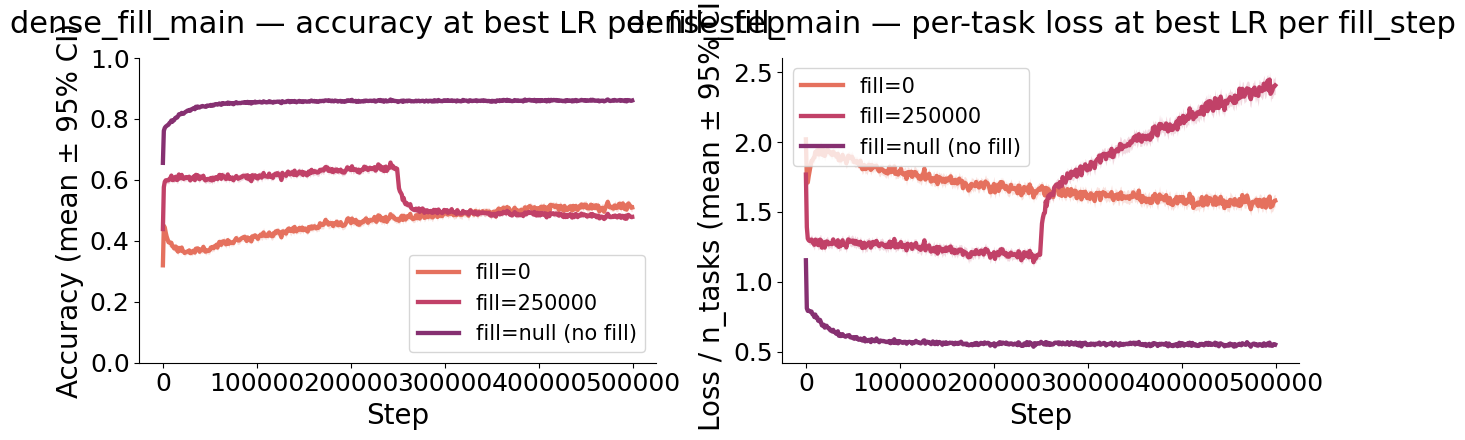

In [41]:
fill_steps = sorted(best_cfg['model.dense_fill_step'].unique())
palette = sns.color_palette('flare', n_colors=len(fill_steps))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for fs, color in zip(fill_steps, palette):
    rids = best_cfg[best_cfg['model.dense_fill_step'] == fs]['run_id'].tolist()
    losses, accs = stack_per_seed(asset_dict, rids)
    if losses is None:
        continue
    steps = np.arange(losses.shape[0]) * 1000
    fs_label = 'null (no fill)' if fs >= 600000 else str(int(fs))
    plot_ci_curve(steps, accs,       label=f'fill={fs_label}', color=color, ax=axes[0])
    plot_ci_curve(steps, losses / 16, label=f'fill={fs_label}', color=color, ax=axes[1])
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Accuracy (mean ± 95% CI)')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Loss / n_tasks (mean ± 95% CI)')
axes[0].set_title('dense_fill_main — accuracy at best LR per fill_step')
axes[1].set_title('dense_fill_main — per-task loss at best LR per fill_step')
axes[0].legend(loc='best'); axes[1].legend(loc='best')
axes[0].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 2. n_task_scaling: 4-method comparison

All four methods sweep `task.n_tasks ∈ {2,4,8,16,32}` × a size axis × LRs. The size axis differs by method:

| Method | Size axis | Grid |
|---|---|---|
| Block-Sparse | `model.initial_hidden_units` | 4, 8, ..., 512 |
| Dense | `model.initial_hidden_units` | 4, 8, ..., 512 |
| Random-Sparse | `model.initial_hidden_units` | 48, 96, ..., 1536 (per-unit sparsity fixed at 03 winner) |
| Structure-Search | `structure_search.connection_budget` | 4764, ..., 152448 (max_hidden/prune/units proportional) |

In [42]:
METHODS = [
    ('n_block_sparse',     'Block-Sparse',     'model.initial_hidden_units'),
    ('n_dense',            'Dense',            'model.initial_hidden_units'),
    ('n_random_sparse',    'Random-Sparse',    'model.initial_hidden_units'),
    ('n_structure_search', 'Structure-Search', 'structure_search.connection_budget'),
]
METHOD_PALETTE = get_color_palette(classes=[m[1] for m in METHODS])

for key, label, size_col in METHODS:
    c, r = filter_sweep(key)
    print(f'{label:18s}  trials={len(c):4d}  sizes={sorted(c[size_col].dropna().unique().tolist())}')

Block-Sparse        trials= 145  sizes=[4, 8, 16, 32, 64, 128, 256, 512]
Dense               trials= 174  sizes=[4, 8, 16, 32, 64, 128, 256, 512]
Random-Sparse       trials= 126  sizes=[48, 96, 192, 384, 768, 1536]
Structure-Search    trials= 130  sizes=[4764, 9528, 19056, 38112, 76224, 152448]


### 2a. Per-method: asymptotic accuracy vs size, hue = n_tasks (best LR per cell)

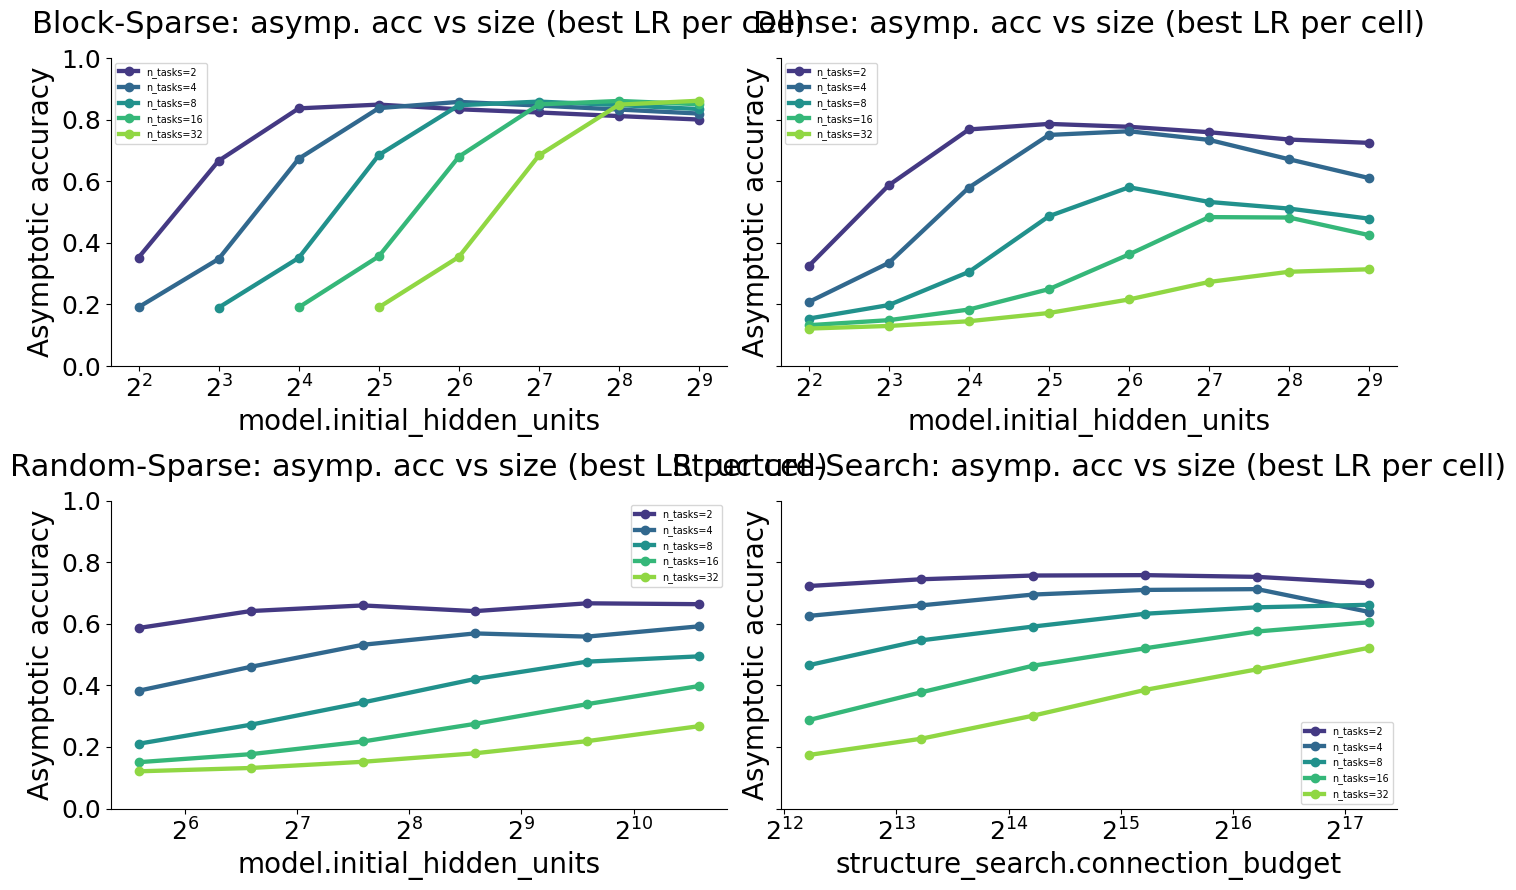

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
for ax, (key, label, size_col) in zip(axes.flatten(), METHODS):
    cfg, run = filter_sweep(key)
    if len(cfg) == 0:
        ax.set_title(f'{label} — no data'); continue
    asym = asymptotic_metric(cfg, run, 'accuracy', group_cols=['task.n_tasks', size_col])
    # idxmax may return NaN for groups whose every LR diverged (all-NaN row);
    # drop those before .loc, otherwise pandas raises '[nan] not in index'.
    idxs = asym.groupby(['task.n_tasks', size_col])['_metric'].idxmax().dropna()
    best = asym.loc[idxs.astype(int)].sort_values(['task.n_tasks', size_col])
    n_palette = sns.color_palette('viridis', n_colors=best['task.n_tasks'].nunique())
    for color, (n_t, sub) in zip(n_palette, best.groupby('task.n_tasks')):
        ax.plot(sub[size_col], sub['_metric'], '-o',
                color=color, label=f'n_tasks={int(n_t)}')
    ax.set_xscale('log', base=2)
    ax.set_xlabel(size_col)
    ax.set_ylabel('Asymptotic accuracy')
    ax.set_title(f'{label}: asymp. acc vs size (best LR per cell)')
    ax.set_ylim(0, 1)
    ax.legend(fontsize='x-small', loc='best')
plt.tight_layout()
plt.show()

### 2b. Cross-method: best-tuned asymptotic accuracy vs n_tasks

For each method, picks the best `(size, LR)` combination at each `n_tasks` value and plots that single point. Direct head-to-head.

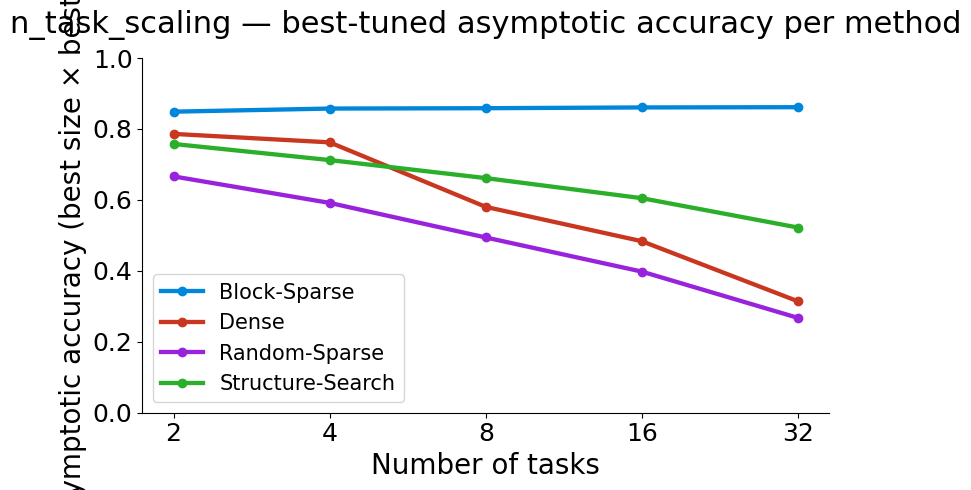

,Method,n_tasks,size,lr,asym_acc
0,Block-Sparse,2,32.0,0.003906,0.848700
1,Block-Sparse,4,64.0,0.003906,0.857486
2,Block-Sparse,8,128.0,0.003906,0.858463
3,Block-Sparse,16,256.0,0.003906,0.860618
4,Block-Sparse,32,512.0,0.003906,0.861312
5,Dense,2,32.0,0.001953,0.786020
6,Dense,4,64.0,0.001953,0.762208
7,Dense,8,64.0,0.001953,0.580320
8,Dense,16,128.0,0.000488,0.483485
9,Dense,32,512.0,0.000488,0.314118


In [44]:
records = []
for key, label, size_col in METHODS:
    cfg, run = filter_sweep(key)
    if len(cfg) == 0:
        continue
    asym = asymptotic_metric(cfg, run, 'accuracy', group_cols=['task.n_tasks', size_col])
    idxs = asym.groupby(['task.n_tasks'])['_metric'].idxmax().dropna()
    best = asym.loc[idxs.astype(int)]
    for _, r in best.iterrows():
        records.append({
            'Method': label, 'n_tasks': int(r['task.n_tasks']),
            'size': r[size_col], 'lr': r['optimizer.learning_rate'], 'asym_acc': r['_metric'],
        })
df_best = pd.DataFrame(records)

plt.figure(figsize=(8, 5))
for label in [m[1] for m in METHODS]:
    sub = df_best[df_best['Method'] == label].sort_values('n_tasks')
    plt.plot(sub['n_tasks'], sub['asym_acc'], '-o',
             color=METHOD_PALETTE[label], label=label)
plt.xscale('log', base=2)
plt.xticks([2, 4, 8, 16, 32], [2, 4, 8, 16, 32])
plt.xlabel('Number of tasks')
plt.ylabel('Asymptotic accuracy (best size × best LR)')
plt.title('n_task_scaling — best-tuned asymptotic accuracy per method')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

df_best

### 2c. Cross-method learning curves with 95% CI (n_tasks = 4, best size × best LR per method)

Per-seed `.npy` assets feed the CI bands. 5 atomic seeds per trial.

fetch per-seed: 100%|██████████| 1/1 [00:00<00:00, 10255.02it/s]


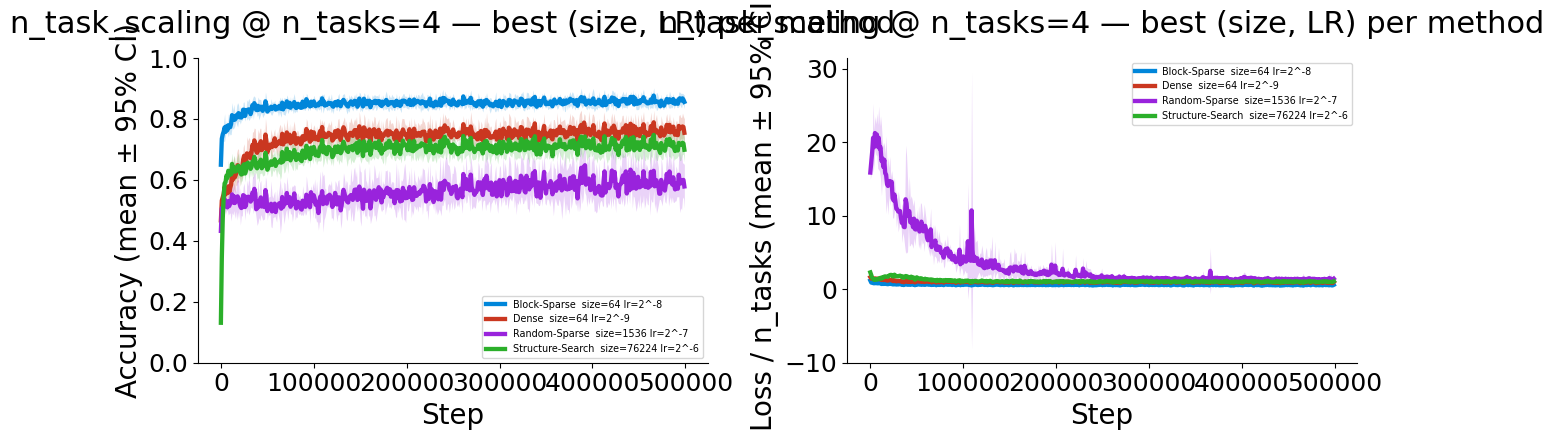

In [45]:
TARGET_N_TASKS = 4
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for key, label, size_col in METHODS:
    cfg, run = filter_sweep(key)
    cfg = cfg[cfg['task.n_tasks'] == TARGET_N_TASKS].copy()
    run = run[run['run_id'].isin(cfg['run_id'])].copy()
    if len(cfg) == 0:
        continue
    asym = asymptotic_metric(cfg, run, 'accuracy', group_cols=[size_col])
    if asym['_metric'].notna().sum() == 0:
        continue
    row = asym.loc[asym['_metric'].idxmax()]
    best_size, best_lr = row[size_col], row['optimizer.learning_rate']
    rids = cfg[(cfg[size_col] == best_size)
               & (cfg['optimizer.learning_rate'] == best_lr)]['run_id'].tolist()
    assets = fetch_per_seed_arrays(rids)
    losses, accs = stack_per_seed(assets, rids)
    if losses is None:
        continue
    steps = np.arange(losses.shape[0]) * 1000
    lr_log2 = int(np.log2(best_lr))
    legend = f'{label}  size={int(best_size)} lr=2^{lr_log2}'
    plot_ci_curve(steps, accs, label=legend, color=METHOD_PALETTE[label], ax=axes[0])
    plot_ci_curve(steps, losses / TARGET_N_TASKS, label=legend, color=METHOD_PALETTE[label], ax=axes[1])
axes[0].set_xlabel('Step'); axes[0].set_ylabel('Accuracy (mean ± 95% CI)')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Loss / n_tasks (mean ± 95% CI)')
axes[0].set_title(f'n_task_scaling @ n_tasks={TARGET_N_TASKS} — best (size, LR) per method')
axes[1].set_title(f'n_task_scaling @ n_tasks={TARGET_N_TASKS} — best (size, LR) per method')
axes[0].legend(fontsize='x-small', loc='best')
axes[1].legend(fontsize='x-small', loc='best')
axes[0].set_ylim(0, 1)
plt.tight_layout()
plt.show()

### 2d. LR-sensitivity per method (n_tasks = 4)

Verifies the LR grid spans the optimum at one representative n_tasks. Each panel shows asymptotic accuracy vs LR with hue = size axis.

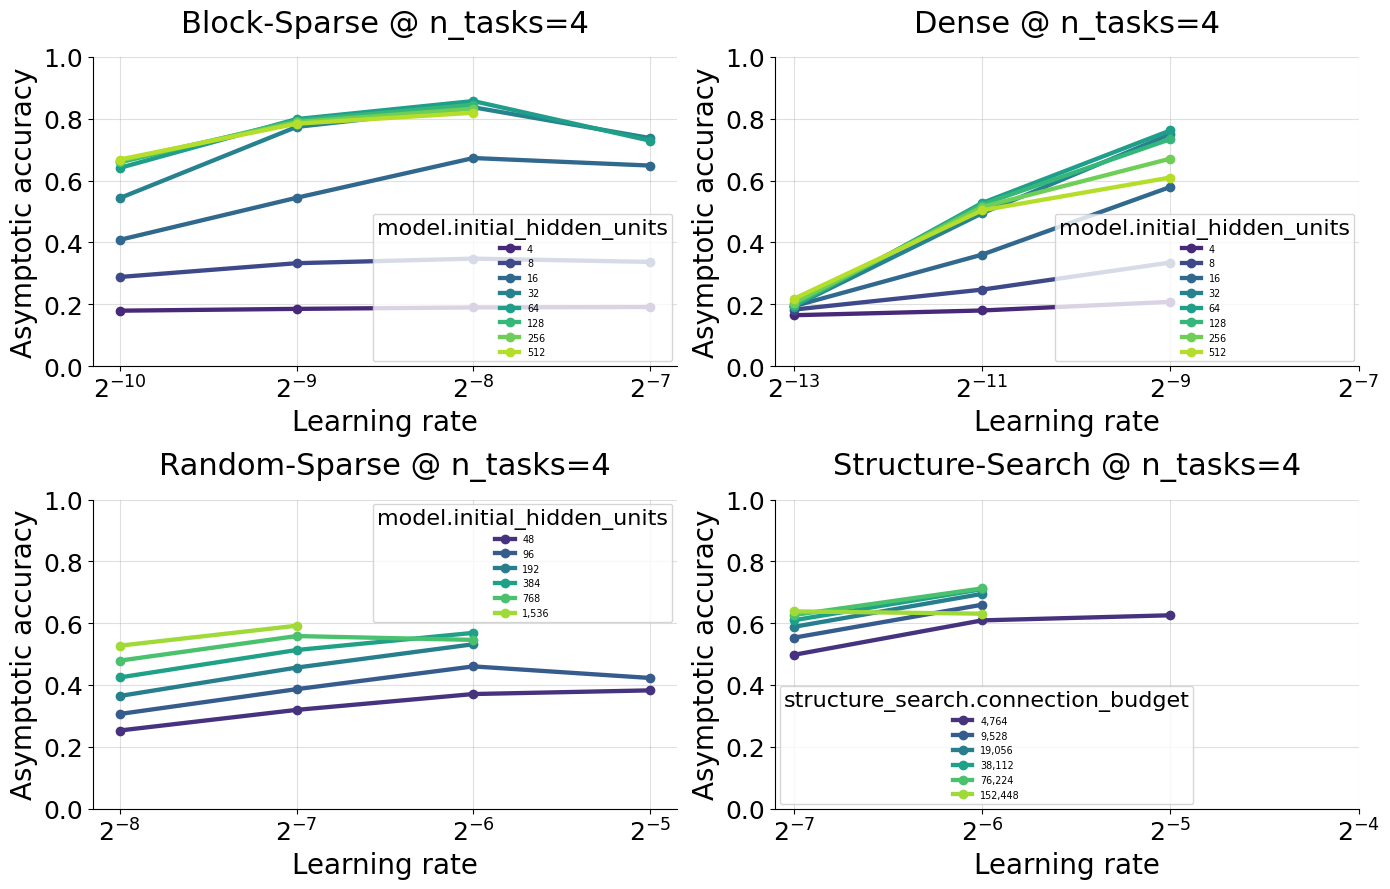

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (key, label, size_col) in zip(axes.flatten(), METHODS):
    cfg, run = filter_sweep(key)
    cfg = cfg[cfg['task.n_tasks'] == TARGET_N_TASKS].copy()
    run = run[run['run_id'].isin(cfg['run_id'])].copy()
    if len(cfg) == 0:
        ax.set_title(f'{label} — no data'); continue
    asym = asymptotic_metric(cfg, run, 'accuracy', group_cols=[size_col])
    n_sizes = asym[size_col].nunique()
    palette = sns.color_palette('viridis', n_colors=n_sizes)
    plot_lr_sensitivity(
        asym, ax=ax,
        hue_col=size_col, palette=palette,
        title=f'{label} @ n_tasks={TARGET_N_TASKS}',
        xlabel='Learning rate', ylabel='Asymptotic accuracy',
        ylim=(0, 1), legend_title=size_col,
    )
plt.tight_layout()
plt.show()